# 🍔 Food Delivery Analytics and Intelligent Recommendation System

**Dataset:** 7 relational sheets — Customers, Restaurants, Menu, Orders, OrderItems, Payments, Delivery

---
| Part | Topic | Marks |
|------|-------|-------|
| 1 | Data Integration & Preprocessing | 10 |
| 2 | Association Rule Mining | 10 |
| 3 | Classification | 10 |
| 4 | Clustering | 10 |
| 5 | ANN (Neural Network) | 10 |

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import seaborn as sns
from itertools import combinations
from collections import defaultdict
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score,
                             f1_score, mean_squared_error, r2_score)
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')
print('All libraries loaded successfully')

All libraries loaded successfully


---
## PART 1: Data Integration & Preprocessing

### 1.1 Load All Sheets

In [2]:
FILE = 'Food_Delivery_STRICT_RELATIONAL.xlsx'
sheets = pd.read_excel(FILE, sheet_name=None)

customers   = sheets['Customers']
restaurants = sheets['Restaurants']
menu        = sheets['Menu']
orders      = sheets['Orders']
order_items = sheets['OrderItems']
payments    = sheets['Payments']
delivery    = sheets['Delivery']

for name, df in sheets.items():
    print(f'{name:15s} -> {df.shape[0]:,} rows x {df.shape[1]} cols  |  columns: {list(df.columns)}')

Customers       -> 50,000 rows x 4 cols  |  columns: ['CustomerID', 'Age', 'Gender', 'City']
Restaurants     -> 500 rows x 4 cols  |  columns: ['RestaurantID', 'Cuisine', 'City', 'Rating']
Menu            -> 50,000 rows x 4 cols  |  columns: ['ItemID', 'RestaurantID', 'ItemName', 'Price']
Orders          -> 50,000 rows x 4 cols  |  columns: ['OrderID', 'CustomerID', 'RestaurantID', 'OrderDate']
OrderItems      -> 50,000 rows x 4 cols  |  columns: ['OrderItemID', 'OrderID', 'ItemID', 'Quantity']
Payments        -> 50,000 rows x 4 cols  |  columns: ['PaymentID', 'OrderID', 'Amount', 'Mode']
Delivery        -> 50,000 rows x 4 cols  |  columns: ['DeliveryID', 'OrderID', 'DeliveryTime(min)', 'Status']


### 1.2 Explore & Check Missing Values

In [3]:
print('=== CUSTOMERS ===')
display(customers.head(3))
print('=== DELIVERY ===')
display(delivery.head(3))

print('--- Missing values per sheet ---')
for name, df in sheets.items():
    missing = df.isnull().sum().sum()
    print(f'  {name:15s}: {missing} missing values')

=== CUSTOMERS ===


,CustomerID,Age,Gender,City
0,1,42,Male,Delhi
1,2,27,Female,Mumbai
2,3,32,Female,Mumbai


=== DELIVERY ===


,DeliveryID,OrderID,DeliveryTime(min),Status
0,1,1,58,Late
1,2,2,16,Late
2,3,3,56,Cancelled


--- Missing values per sheet ---
  Customers      : 0 missing values
  Restaurants    : 0 missing values
  Menu           : 0 missing values
  Orders         : 0 missing values
  OrderItems     : 0 missing values
  Payments       : 0 missing values
  Delivery       : 0 missing values


### 1.3 Merge All Sheets

In [4]:
# Step 1: Orders + Customers
df = orders.merge(customers, on='CustomerID', how='left')

# Step 2: + Restaurants
df = df.merge(restaurants, on='RestaurantID', how='left', suffixes=('_customer', '_restaurant'))

# Step 3: + Payments
df = df.merge(payments, on='OrderID', how='left')

# Step 4: + Delivery
df = df.merge(delivery, on='OrderID', how='left')

# Step 5: Order-level item summary (total items & avg price per order)
oi_enriched = order_items.merge(menu, on='ItemID', how='left')
order_summary = oi_enriched.groupby('OrderID').agg(
    ItemsPerOrder=('Quantity', 'sum'),
    UniqueItems=('ItemID', 'nunique'),
    AvgItemPrice=('Price', 'mean')
).reset_index()

df = df.merge(order_summary, on='OrderID', how='left')

print(f'Merged DataFrame: {df.shape[0]:,} rows x {df.shape[1]} columns')
display(df.head(3))

Merged DataFrame: 50,000 rows x 19 columns


,OrderID,CustomerID,RestaurantID,OrderDate,Age,Gender,City_customer,Cuisine,City_restaurant,Rating,PaymentID,Amount,Mode,DeliveryID,DeliveryTime(min),Status,ItemsPerOrder,UniqueItems,AvgItemPrice
0,1,21691,94,2023-06-12,34,Female,Pune,Dessert,Delhi,4.4,1,1054,Card,1,58,Late,2,1,463.0
1,2,24495,43,2023-11-21,59,Male,Chennai,Chinese,Mumbai,4.0,2,979,UPI,2,16,Late,1,1,211.0
2,3,2430,151,2023-08-04,39,Male,Delhi,Chinese,Pune,2.6,3,322,Card,3,56,Cancelled,2,1,424.0


### 1.4 Derived Features

In [5]:
# Total order value from Payments
df['TotalOrderValue'] = df['Amount']

# Order date features
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['OrderMonth']     = df['OrderDate'].dt.month
df['OrderDayOfWeek'] = df['OrderDate'].dt.dayofweek
df['OrderHour']      = df['OrderDate'].dt.hour

# Customer order frequency
cust_freq = df.groupby('CustomerID')['OrderID'].count().rename('CustomerOrderFrequency')
df = df.merge(cust_freq, on='CustomerID', how='left')

# Average delivery time per customer
avg_del = df.groupby('CustomerID')['DeliveryTime(min)'].mean().rename('AvgDeliveryTime')
df = df.merge(avg_del, on='CustomerID', how='left')

# Rename for clarity
df.rename(columns={'DeliveryTime(min)': 'DeliveryTime'}, inplace=True)

new_cols = ['TotalOrderValue','OrderMonth','OrderDayOfWeek','ItemsPerOrder',
            'CustomerOrderFrequency','AvgDeliveryTime']
print('Derived feature statistics:')
display(df[new_cols].describe().round(2))

Derived feature statistics:


,TotalOrderValue,OrderMonth,OrderDayOfWeek,ItemsPerOrder,CustomerOrderFrequency,AvgDeliveryTime
count,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,849.76,6.52,3.00,2.98,2.01,37.54
std,375.69,3.45,2.01,1.41,1.00,10.57
min,200.00,1.00,0.00,1.00,1.00,15.00
25%,526.00,4.00,1.00,2.00,1.00,30.00
50%,851.00,7.00,3.00,3.00,2.00,37.50
75%,1174.00,10.00,5.00,4.00,3.00,45.00
max,1500.00,12.00,6.00,5.00,8.00,60.00


### 1.5 Encode Categorical Variables

In [6]:
le = LabelEncoder()
cat_cols = ['Cuisine', 'City_customer', 'Mode', 'Gender']

for col in cat_cols:
    if col in df.columns:
        df[col + '_enc'] = le.fit_transform(df[col].astype(str))
        print(f'{col}: {df[col].nunique()} unique values -> encoded')

# Encode delivery status
df['Status_enc'] = le.fit_transform(df['Status'].astype(str))
print(f"\nDelivery Status classes: {df['Status'].unique()}")
display(df['Status'].value_counts())

# Drop rows with missing targets
df.dropna(subset=['DeliveryTime', 'TotalOrderValue', 'Status'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'\nFinal merged dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')

Cuisine: 5 unique values -> encoded
City_customer: 5 unique values -> encoded
Mode: 4 unique values -> encoded
Gender: 2 unique values -> encoded

Delivery Status classes: ['Late' 'Cancelled' 'OnTime']


,count
Status,
Late,16841
OnTime,16622
Cancelled,16537



Final merged dataset: 50,000 rows x 30 columns


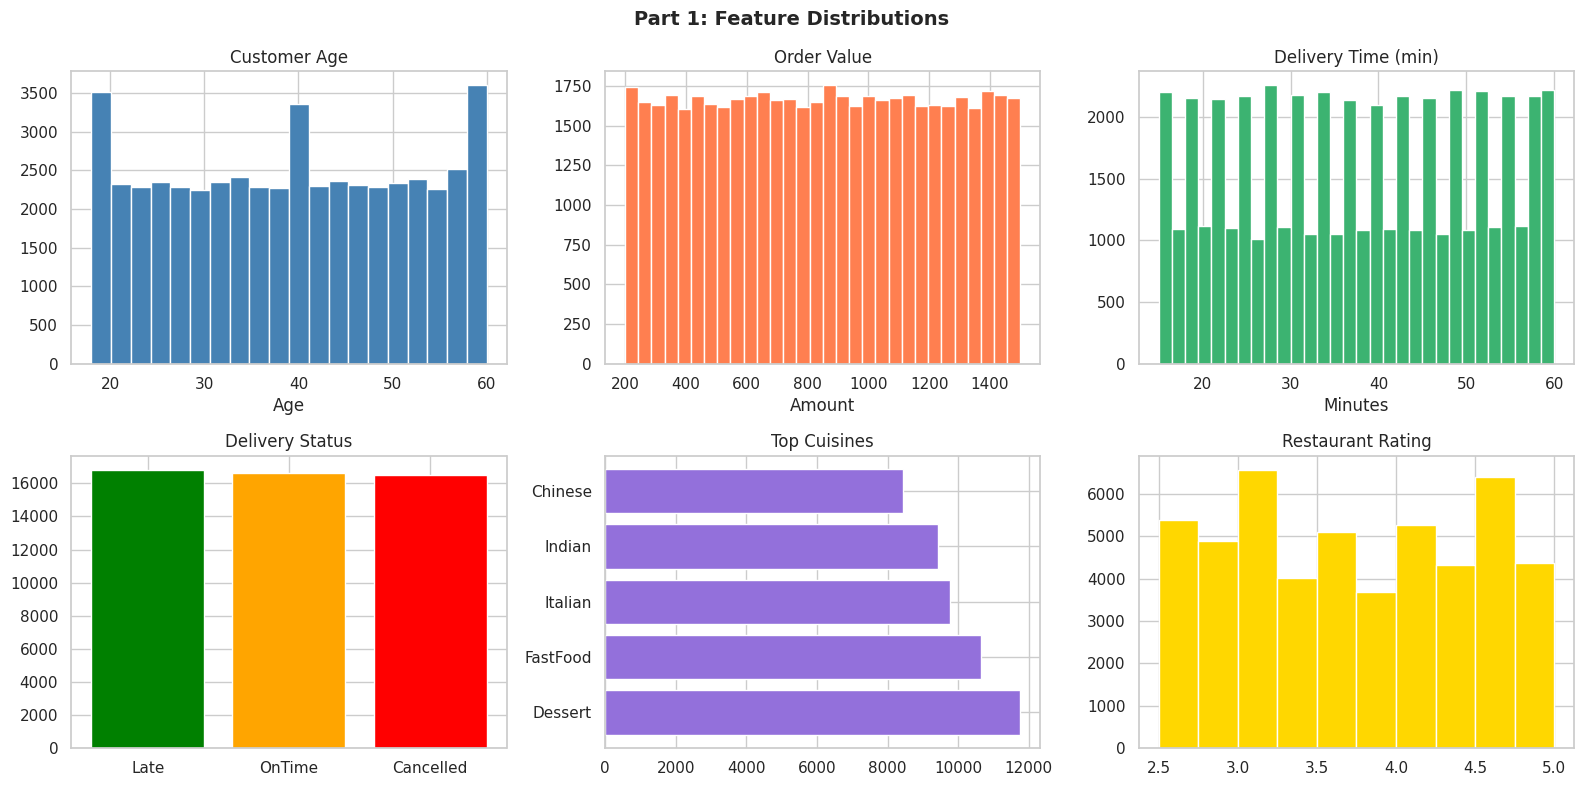

Part 1 complete


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Part 1: Feature Distributions', fontsize=14, fontweight='bold')

axes[0,0].hist(df['Age'], bins=20, color='steelblue', edgecolor='white')
axes[0,0].set_title('Customer Age'); axes[0,0].set_xlabel('Age')

axes[0,1].hist(df['TotalOrderValue'], bins=30, color='coral', edgecolor='white')
axes[0,1].set_title('Order Value'); axes[0,1].set_xlabel('Amount')

axes[0,2].hist(df['DeliveryTime'], bins=30, color='mediumseagreen', edgecolor='white')
axes[0,2].set_title('Delivery Time (min)'); axes[0,2].set_xlabel('Minutes')

status_counts = df['Status'].value_counts()
axes[1,0].bar(status_counts.index, status_counts.values, color=['green','orange','red'])
axes[1,0].set_title('Delivery Status')

cuisine_counts = df['Cuisine'].value_counts().head(8)
axes[1,1].barh(cuisine_counts.index, cuisine_counts.values, color='mediumpurple')
axes[1,1].set_title('Top Cuisines')

axes[1,2].hist(df['Rating'], bins=10, color='gold', edgecolor='white')
axes[1,2].set_title('Restaurant Rating')

plt.tight_layout()
plt.show()
print('Part 1 complete')

---
## PART 2: Association Rule Mining

**Objective:** Discover patterns: Food Items <-> Cuisine <-> Order Behavior

### 2.1 Build Transaction Dataset

In [8]:
# This dataset has 1 item per order. We build CUSTOMER-LEVEL baskets:
# Each customer's cuisine + payment mode history = one transaction.
oi_full = order_items.merge(menu, on='ItemID', how='left')
oi_full = oi_full.merge(restaurants[['RestaurantID','Cuisine']], on='RestaurantID', how='left')
oi_full = oi_full.merge(orders[['OrderID','CustomerID']], on='OrderID', how='left')
oi_full = oi_full.merge(payments[['OrderID','Mode']], on='OrderID', how='left')

oi_full['CuisineItem'] = 'Cuisine_' + oi_full['Cuisine'].astype(str)
oi_full['PayItem']     = 'Pay_'     + oi_full['Mode'].astype(str)

def build_basket(group):
    return list(set(group['CuisineItem'].tolist() + group['PayItem'].tolist()))

transactions = oi_full.groupby('CustomerID').apply(build_basket).tolist()

print(f'Total customer baskets: {len(transactions):,}')
print(f'Avg items per basket: {sum(len(t) for t in transactions)/len(transactions):.2f}')
print(f'Sample basket: {transactions[0]}')

Total customer baskets: 31,530
Avg items per basket: 2.84
Sample basket: ['Pay_Wallet', 'Cuisine_FastFood']


### 2.2 Apriori Algorithm

In [9]:
def get_support(itemset, transactions):
    count = sum(1 for t in transactions if set(itemset).issubset(set(t)))
    return count / len(transactions)

def apriori(transactions, min_support=0.02, min_confidence=0.3):
    all_items = set(item for t in transactions for item in t)
    C1 = [{item} for item in all_items]
    L1 = {frozenset(i): get_support(i, transactions) for i in C1
          if get_support(i, transactions) >= min_support}
    freq_itemsets = dict(L1)
    current_L = list(L1.keys())
    k = 2
    while current_L:
        candidates = set()
        for i in range(len(current_L)):
            for j in range(i+1, len(current_L)):
                union = current_L[i] | current_L[j]
                if len(union) == k:
                    candidates.add(union)
        Lk = {c: get_support(c, transactions) for c in candidates
              if get_support(c, transactions) >= min_support}
        freq_itemsets.update(Lk)
        current_L = list(Lk.keys())
        k += 1
        if k > 3:
            break
    rules = []
    for itemset, support in freq_itemsets.items():
        if len(itemset) < 2:
            continue
        for size in range(1, len(itemset)):
            for antecedent in combinations(itemset, size):
                antecedent = frozenset(antecedent)
                consequent = itemset - antecedent
                ant_sup = freq_itemsets.get(antecedent, get_support(antecedent, transactions))
                if ant_sup == 0:
                    continue
                confidence = support / ant_sup
                if confidence >= min_confidence:
                    cons_sup = freq_itemsets.get(consequent, get_support(consequent, transactions))
                    lift = confidence / cons_sup if cons_sup > 0 else 0
                    rules.append({
                        'antecedents': set(antecedent),
                        'consequents': set(consequent),
                        'support':    round(support, 4),
                        'confidence': round(confidence, 4),
                        'lift':       round(lift, 4)
                    })
    return freq_itemsets, rules

print(f'Running Apriori on {len(transactions):,} customer baskets...')
freq_itemsets, rules = apriori(transactions, min_support=0.05, min_confidence=0.3)
print(f'Frequent itemsets: {len(freq_itemsets)}')



Running Apriori on 31,530 customer baskets...
Frequent itemsets: 41


### 2.3 FP-Growth Algorithm

In [10]:
class FPNode:
    def __init__(self, item, count=0, parent=None):
        self.item = item; self.count = count
        self.parent = parent; self.children = {}; self.link = None

def build_fp_tree(txns, min_sup_count):
    item_counts = defaultdict(int)
    for t in txns:
        for item in t:
            item_counts[item] += 1
    freq_items = {k: v for k, v in item_counts.items() if v >= min_sup_count}
    if not freq_items:
        return None, None
    header_table = {item: [count, None] for item, count in freq_items.items()}
    root = FPNode('null', 1, None)
    for transaction in txns:
        sorted_items = sorted([i for i in transaction if i in freq_items],
                              key=lambda x: freq_items[x], reverse=True)
        if not sorted_items:
            continue
        current = root
        for item in sorted_items:
            if item in current.children:
                current.children[item].count += 1
            else:
                new_node = FPNode(item, 1, current)
                current.children[item] = new_node
                if header_table[item][1] is None:
                    header_table[item][1] = new_node
                else:
                    node = header_table[item][1]
                    while node.link:
                        node = node.link
                    node.link = new_node
            current = current.children[item]
    return root, header_table

def fp_growth_mine(header_table, min_sup_count, prefix, fp_itemsets):
    for item in sorted(header_table.keys(), key=lambda x: header_table[x][0]):
        new_prefix = prefix | {item}
        fp_itemsets[frozenset(new_prefix)] = header_table[item][0]
        cond_patterns = []
        node = header_table[item][1]
        while node:
            path = []
            parent = node.parent
            while parent and parent.item != 'null':
                path.append(parent.item)
                parent = parent.parent
            cond_patterns.extend([path] * node.count)
            node = node.link
        if cond_patterns:
            _, cond_header = build_fp_tree(cond_patterns, min_sup_count)
            if cond_header:
                fp_growth_mine(cond_header, min_sup_count, new_prefix, fp_itemsets)

# Use same transactions list built in 2.1 (customer-level baskets)
min_sup_count = int(0.05 * len(transactions))
_, header_table = build_fp_tree(transactions, min_sup_count)
fp_itemsets = {}
if header_table:
    fp_growth_mine(header_table, min_sup_count, set(), fp_itemsets)
print(f'FP-Growth frequent itemsets: {len(fp_itemsets)}')

FP-Growth frequent itemsets: 41


### 2.4 Results & Business Questions

In [11]:
rules_df = pd.DataFrame(rules)
rules_df['antecedents'] = rules_df['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules_df['consequents'] = rules_df['consequents'].apply(lambda x: ', '.join(sorted(x)))
rules_df = rules_df.sort_values('lift', ascending=False)

print('Top 15 Association Rules by Lift:')
display(rules_df[['antecedents','consequents','support','confidence','lift']].head(15))

# Q1: Which cuisines are frequently ordered together by the same customers?
cuisine_rules = rules_df[rules_df['antecedents'].str.startswith('Cuisine_') &
                         rules_df['consequents'].str.startswith('Cuisine_')]
print('\nQ1: Cuisines frequently ordered together by same customers:')
display(cuisine_rules[['antecedents','consequents','support','confidence','lift']].head(8))

# Q2: Which cuisine leads to high-value orders?
cuisine_order = df.groupby('Cuisine')['TotalOrderValue'].mean().sort_values(ascending=False)
print('\nQ2: Cuisine -> Average Order Value:')
display(cuisine_order.head(10).reset_index())

# Q3: Which cuisine+payment combinations are most common?
cross_rules = rules_df[rules_df['antecedents'].str.startswith('Cuisine_') &
                        rules_df['consequents'].str.startswith('Pay_')]
print('\nQ3: Cuisine -> Payment Mode associations (basket builders):')
display(cross_rules[['antecedents','consequents','support','confidence','lift']].head(8))

Top 15 Association Rules by Lift:


,antecedents,consequents,support,confidence,lift
3,Cuisine_Indian,Pay_Card,0.1144,0.4182,1.1859
2,Pay_Card,Cuisine_Indian,0.1144,0.3245,1.1859
17,Cuisine_Italian,Pay_Wallet,0.1171,0.4164,1.1812
16,Pay_Wallet,Cuisine_Italian,0.1171,0.3321,1.1812
31,Cuisine_Chinese,Pay_UPI,0.1012,0.4093,1.1757
18,Cuisine_Indian,Pay_Cash,0.1111,0.4059,1.1651
19,Pay_Cash,Cuisine_Indian,0.1111,0.3188,1.1651
25,Cuisine_FastFood,Pay_UPI,0.1211,0.3996,1.1478
24,Pay_UPI,Cuisine_FastFood,0.1211,0.3479,1.1478
27,Cuisine_Dessert,Pay_UPI,0.1328,0.3995,1.1477



Q1: Cuisines frequently ordered together by same customers:


,antecedents,consequents,support,confidence,lift



Q2: Cuisine -> Average Order Value:


,Cuisine,TotalOrderValue
0,FastFood,852.057409
1,Italian,851.798792
2,Chinese,849.601875
3,Indian,848.027173
4,Dessert,847.489692



Q3: Cuisine -> Payment Mode associations (basket builders):


,antecedents,consequents,support,confidence,lift
3,Cuisine_Indian,Pay_Card,0.1144,0.4182,1.1859
17,Cuisine_Italian,Pay_Wallet,0.1171,0.4164,1.1812
31,Cuisine_Chinese,Pay_UPI,0.1012,0.4093,1.1757
18,Cuisine_Indian,Pay_Cash,0.1111,0.4059,1.1651
25,Cuisine_FastFood,Pay_UPI,0.1211,0.3996,1.1478
27,Cuisine_Dessert,Pay_UPI,0.1328,0.3995,1.1477
29,Cuisine_Italian,Pay_Card,0.1138,0.4046,1.1475
13,Cuisine_Dessert,Pay_Wallet,0.1341,0.4035,1.1446


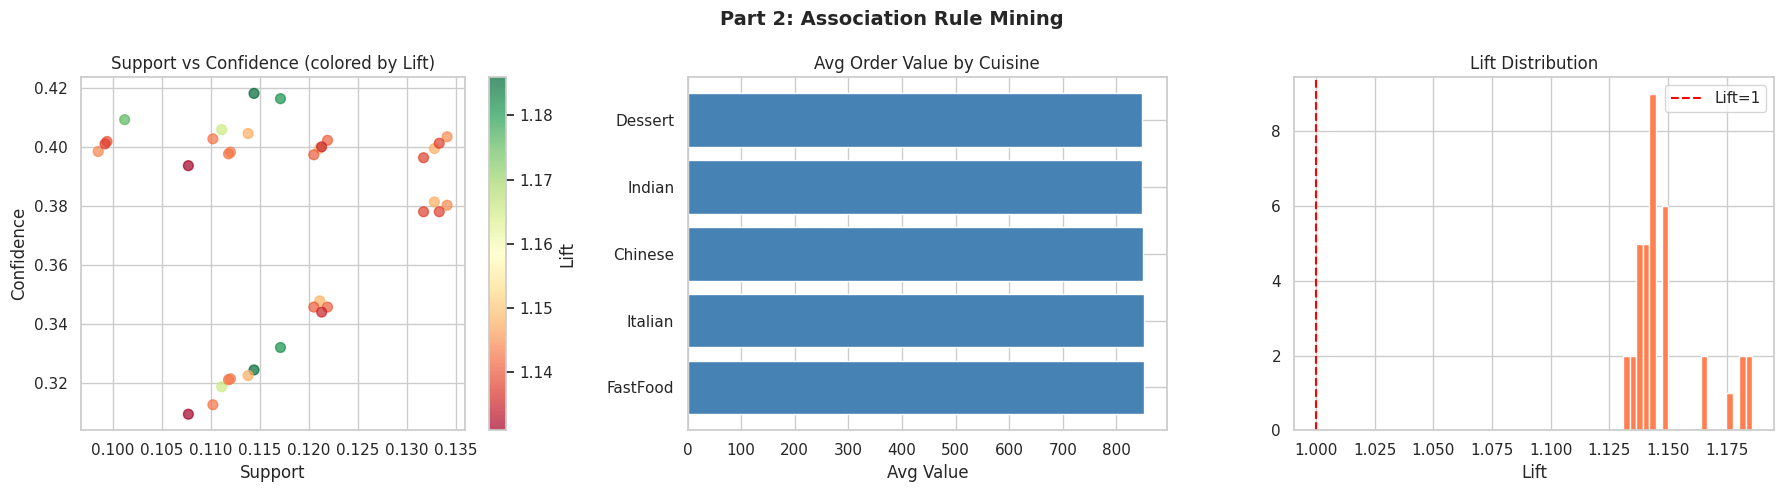

Part 2 complete


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Part 2: Association Rule Mining', fontsize=14, fontweight='bold')

sc = axes[0].scatter(rules_df['support'], rules_df['confidence'],
                     c=rules_df['lift'], cmap='RdYlGn', s=50, alpha=0.7)
plt.colorbar(sc, ax=axes[0], label='Lift')
axes[0].set_xlabel('Support'); axes[0].set_ylabel('Confidence')
axes[0].set_title('Support vs Confidence (colored by Lift)')

top_cuisine = cuisine_order.head(8)
axes[1].barh(top_cuisine.index, top_cuisine.values, color='steelblue')
axes[1].set_title('Avg Order Value by Cuisine')
axes[1].set_xlabel('Avg Value')

axes[2].hist(rules_df['lift'], bins=20, color='coral', edgecolor='white')
axes[2].axvline(1, color='red', linestyle='--', label='Lift=1')
axes[2].set_title('Lift Distribution'); axes[2].set_xlabel('Lift')
axes[2].legend()

plt.tight_layout()
plt.show()
print('Part 2 complete')

---
## PART 3: Classification

**Objective:** Predict Delivery Status -> OnTime / Late / Cancelled

### 3.1 Prepare Features

In [13]:
clf_features = ['Age', 'Rating', 'ItemsPerOrder', 'TotalOrderValue',
                'OrderMonth', 'OrderDayOfWeek',
                'Cuisine_enc', 'City_customer_enc', 'Mode_enc', 'Gender_enc']

clf_df = df[clf_features + ['Status']].dropna()
X = clf_df[clf_features].values
y = clf_df['Status'].values

scaler_clf = StandardScaler()
X_scaled = scaler_clf.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f'Training: {len(X_train):,}  |  Test: {len(X_test):,}')
print('Class distribution:', dict(pd.Series(y).value_counts()))

Training: 40,000  |  Test: 10,000
Class distribution: {'Late': np.int64(16841), 'OnTime': np.int64(16622), 'Cancelled': np.int64(16537)}


### 3.2 Train All Models

In [14]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'SVM':                 SVC(kernel='rbf', random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results[name] = {
        'model': model, 'y_pred': y_pred,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall':    recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1':        f1_score(y_test, y_pred, average='weighted', zero_division=0)
    }
    print(f'{name:22s} -> Accuracy: {results[name]["accuracy"]:.4f}')

Logistic Regression    -> Accuracy: 0.3425
Decision Tree          -> Accuracy: 0.3402
Random Forest          -> Accuracy: 0.3387
SVM                    -> Accuracy: 0.3453


### 3.3 Evaluation

In [15]:
metrics_df = pd.DataFrame([
    {'Model': name, 'Accuracy': v['accuracy'], 'Precision': v['precision'],
     'Recall': v['recall'], 'F1': v['f1']}
    for name, v in results.items()
]).sort_values('F1', ascending=False)

print('Classification Model Comparison:')
display(metrics_df)

best_model_name = metrics_df.iloc[0]['Model']
print(f'\nBest Model: {best_model_name}')
print(f'\nClassification Report ({best_model_name}):')
print(classification_report(y_test, results[best_model_name]['y_pred'], zero_division=0))

Classification Model Comparison:


,Model,Accuracy,Precision,Recall,F1
3,SVM,0.3453,0.344815,0.3453,0.342641
2,Random Forest,0.3387,0.338635,0.3387,0.338591
0,Logistic Regression,0.3425,0.341425,0.3425,0.335924
1,Decision Tree,0.3402,0.341623,0.3402,0.326434



Best Model: SVM

Classification Report (SVM):
              precision    recall  f1-score   support

   Cancelled       0.34      0.28      0.31      3308
        Late       0.35      0.43      0.38      3368
      OnTime       0.35      0.33      0.34      3324

    accuracy                           0.35     10000
   macro avg       0.34      0.34      0.34     10000
weighted avg       0.34      0.35      0.34     10000



In [16]:
# Q: What causes late delivery?
rf_model = results['Random Forest']['model']
feat_imp = pd.Series(rf_model.feature_importances_, index=clf_features).sort_values(ascending=False)
print('Feature Importances (Random Forest):')
display(feat_imp.reset_index().rename(columns={'index':'Feature', 0:'Importance'}))

# Q: Does restaurant rating affect delivery?
print('\nAvg Rating by Delivery Status:')
display(df.groupby('Status')['Rating'].mean().sort_values())

Feature Importances (Random Forest):


,Feature,Importance
0,TotalOrderValue,0.211290
1,Age,0.159437
2,Rating,0.140605
3,OrderMonth,0.105874
4,OrderDayOfWeek,0.088455
5,ItemsPerOrder,0.073387
6,Cuisine_enc,0.071888
7,City_customer_enc,0.069489
8,Mode_enc,0.059561
9,Gender_enc,0.020015



Avg Rating by Delivery Status:


,Rating
Status,
OnTime,3.704410
Late,3.708889
Cancelled,3.721431


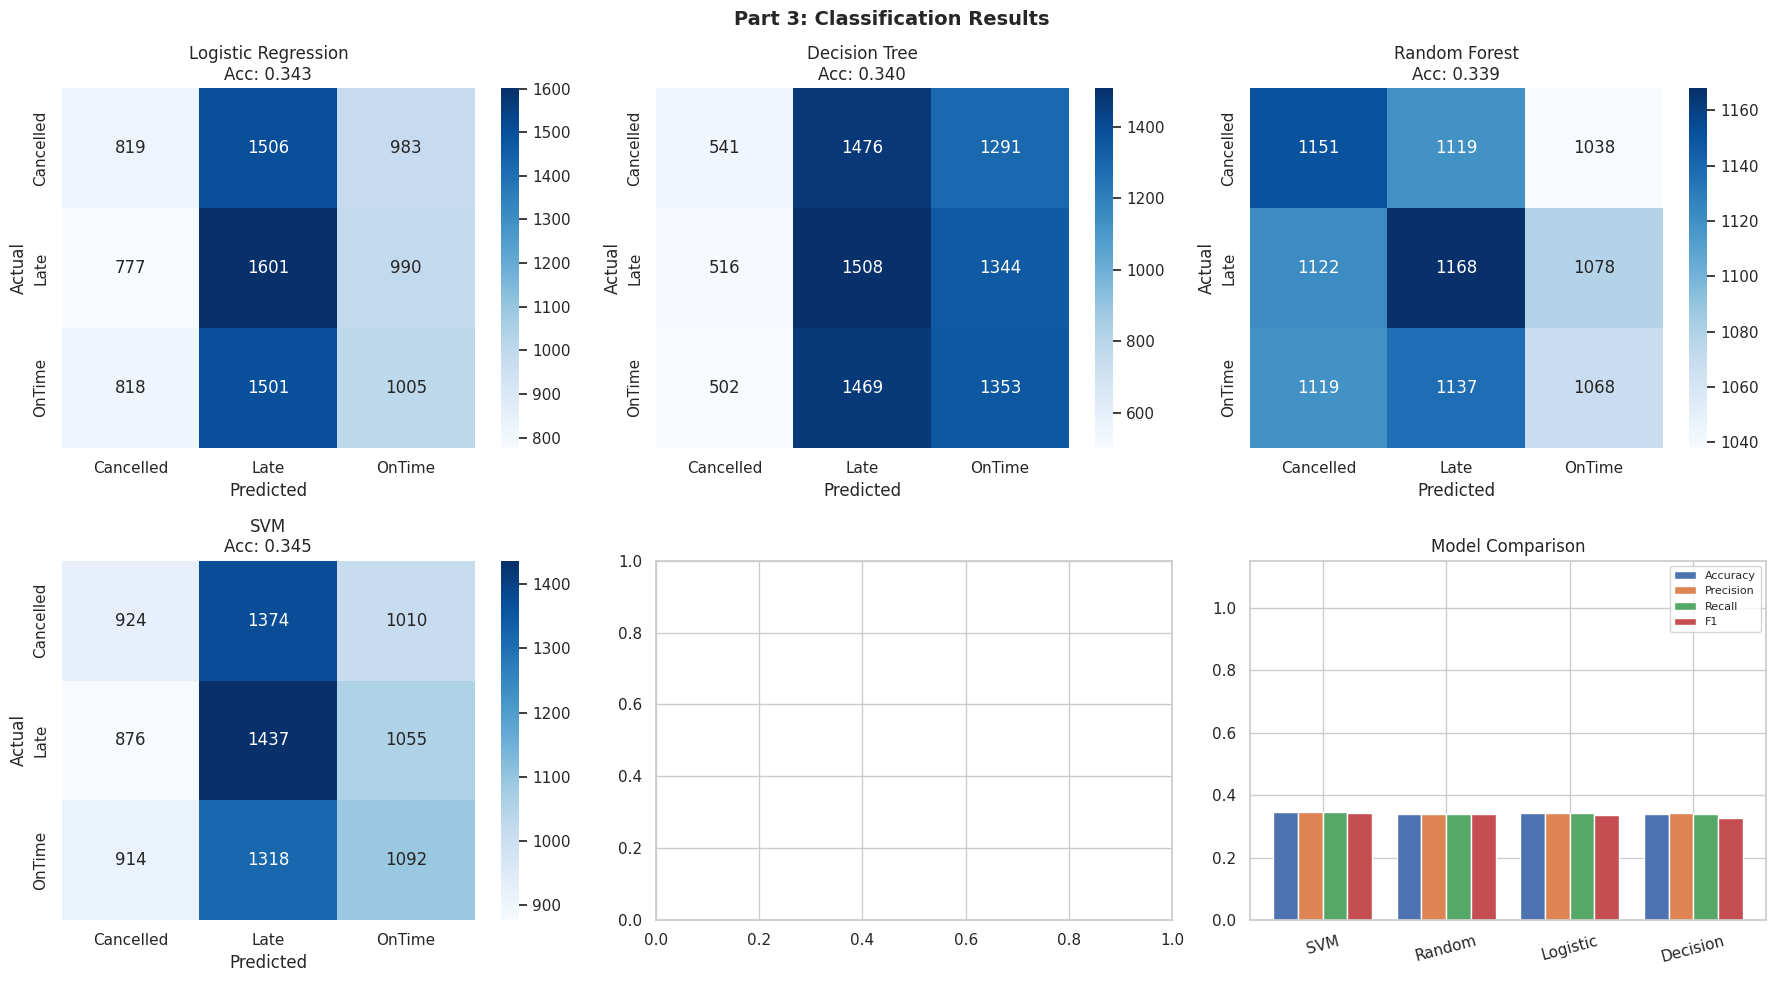

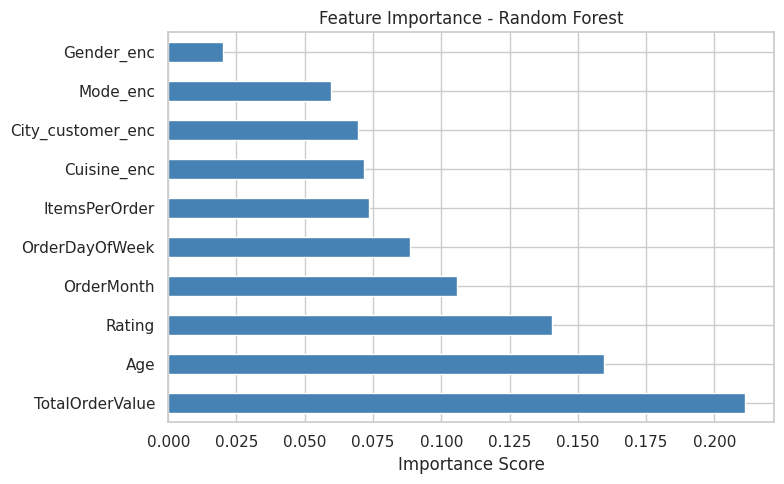

Part 3 complete


In [17]:
labels = sorted(set(y_test))
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Part 3: Classification Results', fontsize=14, fontweight='bold')

for idx, (name, res) in enumerate(results.items()):
    ax = axes[idx // 3][idx % 3]
    cm = confusion_matrix(y_test, res['y_pred'], labels=labels)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=labels, yticklabels=labels)
    ax.set_title(f'{name}\nAcc: {res["accuracy"]:.3f}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

ax = axes[1][2]
x = np.arange(len(metrics_df))
w = 0.2
for i, metric in enumerate(['Accuracy','Precision','Recall','F1']):
    ax.bar(x + i*w, metrics_df[metric], w, label=metric)
ax.set_xticks(x + 1.5*w)
ax.set_xticklabels([n.split()[0] for n in metrics_df['Model']], rotation=15)
ax.set_ylim(0, 1.15); ax.legend(fontsize=8)
ax.set_title('Model Comparison')

plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', ax=ax2, color='steelblue')
ax2.set_title('Feature Importance - Random Forest')
ax2.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()
print('Part 3 complete')

---
## PART 4: Clustering

**Objective:** Segment Customers using K-Means & Hierarchical Clustering

### 4.1 Customer Segmentation Features

In [18]:
cust_seg = df.groupby('CustomerID').agg(
    OrderFrequency=('OrderID', 'count'),
    TotalSpending=('TotalOrderValue', 'sum'),
    AvgOrderValue=('TotalOrderValue', 'mean'),
    AvgDeliveryTime=('DeliveryTime', 'mean'),
    AvgRating=('Rating', 'mean'),
    TotalItems=('ItemsPerOrder', 'sum')
).reset_index()

pref_cuisine = df.groupby(['CustomerID','Cuisine'])['OrderID'].count().reset_index()
pref_cuisine = pref_cuisine.loc[pref_cuisine.groupby('CustomerID')['OrderID'].idxmax()]
pref_cuisine.rename(columns={'Cuisine':'PrefCuisine','OrderID':'CuisineCount'}, inplace=True)
pref_cuisine['PrefCuisine_enc'] = LabelEncoder().fit_transform(pref_cuisine['PrefCuisine'])
cust_seg = cust_seg.merge(pref_cuisine[['CustomerID','PrefCuisine','PrefCuisine_enc']],
                          on='CustomerID', how='left')

seg_features = ['OrderFrequency','TotalSpending','AvgOrderValue',
                'AvgDeliveryTime','AvgRating','PrefCuisine_enc']
X_seg = cust_seg[seg_features].fillna(0).values
X_seg_scaled = StandardScaler().fit_transform(X_seg)

print(f'Customer segmentation shape: {X_seg_scaled.shape}')
display(cust_seg[seg_features].describe().round(2))

Customer segmentation shape: (31530, 6)


,OrderFrequency,TotalSpending,AvgOrderValue,AvgDeliveryTime,AvgRating,PrefCuisine_enc
count,31530.00,31530.00,31530.00,31530.00,31530.00,31530.00
mean,1.59,1347.54,849.81,37.53,3.71,1.69
std,0.82,838.54,328.67,11.65,0.64,1.34
min,1.00,200.00,200.00,15.00,2.50,0.00
25%,1.00,740.00,601.75,29.00,3.20,1.00
50%,1.00,1195.00,852.00,37.50,3.70,1.00
75%,2.00,1759.00,1096.67,46.00,4.20,3.00
max,8.00,6710.00,1500.00,60.00,5.00,4.00


### 4.2 K-Means - Elbow Method

In [19]:
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_seg_scaled)
    inertias.append(km.inertia_)

diffs = np.diff(inertias)
optimal_k = list(K_range)[np.argmax(np.abs(np.diff(diffs))) + 1] if len(diffs) > 1 else 4
print(f'Optimal K (Elbow method): {optimal_k}')

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cust_seg['KMeans_Cluster'] = kmeans.fit_predict(X_seg_scaled)

print('\nCluster Summary (K-Means):')
display(cust_seg.groupby('KMeans_Cluster')[seg_features].mean().round(2))

Optimal K (Elbow method): 3

Cluster Summary (K-Means):


,OrderFrequency,TotalSpending,AvgOrderValue,AvgDeliveryTime,AvgRating,PrefCuisine_enc
KMeans_Cluster,,,,,,
0,2.50,2274.85,927.02,37.54,3.70,1.17
1,1.02,1187.27,1165.79,37.32,3.72,2.11
2,1.22,639.27,523.98,37.69,3.71,1.82


### 4.3 Hierarchical Clustering

In [20]:
sample_idx = np.random.choice(len(X_seg_scaled), size=min(1000, len(X_seg_scaled)), replace=False)
X_hier = X_seg_scaled[sample_idx]

hc = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hier_labels = hc.fit_predict(X_hier)

Z = linkage(X_hier[:200], method='ward')
print(f'Hierarchical clustering done with {optimal_k} clusters')

Hierarchical clustering done with 3 clusters


### 4.4 Cluster Analysis

In [21]:
cluster_profiles = cust_seg.groupby('KMeans_Cluster').agg(
    Count=('CustomerID','count'),
    AvgFrequency=('OrderFrequency','mean'),
    AvgSpending=('TotalSpending','mean'),
    AvgDelivery=('AvgDeliveryTime','mean')
).round(2)

cluster_profiles['Label'] = 'Regular'
max_spend_cluster = cluster_profiles['AvgSpending'].idxmax()
max_freq_cluster  = cluster_profiles['AvgFrequency'].idxmax()
cluster_profiles.loc[max_spend_cluster, 'Label'] = 'High-Value'
cluster_profiles.loc[max_freq_cluster,  'Label'] = 'Frequent'

print('Customer Cluster Profiles:')
display(cluster_profiles)

print(f'\nQ: High-value customers -> Cluster {max_spend_cluster}')
print(f'Q: Highest order frequency -> Cluster {max_freq_cluster}')

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_seg_scaled)
cust_seg['PCA1'] = X_pca[:, 0]
cust_seg['PCA2'] = X_pca[:, 1]

Customer Cluster Profiles:


,Count,AvgFrequency,AvgSpending,AvgDelivery,Label
KMeans_Cluster,,,,,
0,10500,2.50,2274.85,37.54,Frequent
1,9413,1.02,1187.27,37.32,Regular
2,11617,1.22,639.27,37.69,Regular



Q: High-value customers -> Cluster 0
Q: Highest order frequency -> Cluster 0


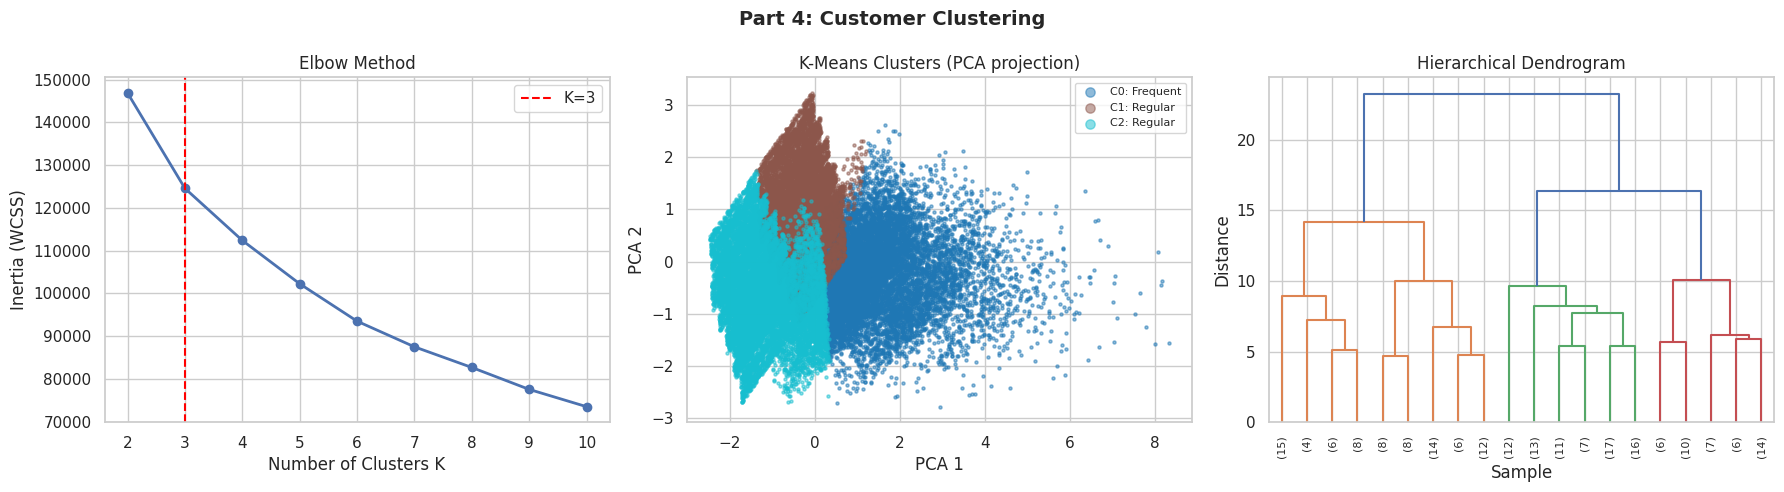

Part 4 complete


In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Part 4: Customer Clustering', fontsize=14, fontweight='bold')

axes[0].plot(K_range, inertias, 'bo-', linewidth=2)
axes[0].axvline(optimal_k, color='red', linestyle='--', label=f'K={optimal_k}')
axes[0].set_xlabel('Number of Clusters K')
axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow Method')
axes[0].legend()

colors = plt.cm.tab10(np.linspace(0, 1, optimal_k))
for c in range(optimal_k):
    mask = cust_seg['KMeans_Cluster'] == c
    label = cluster_profiles.loc[c, 'Label'] if c in cluster_profiles.index else f'C{c}'
    axes[1].scatter(cust_seg.loc[mask,'PCA1'], cust_seg.loc[mask,'PCA2'],
                    s=5, alpha=0.5, color=colors[c], label=f'C{c}: {label}')
axes[1].set_title('K-Means Clusters (PCA projection)')
axes[1].set_xlabel('PCA 1'); axes[1].set_ylabel('PCA 2')
axes[1].legend(markerscale=3, fontsize=8)

dendrogram(Z, ax=axes[2], truncate_mode='lastp', p=20,
           leaf_rotation=90, leaf_font_size=8)
axes[2].set_title('Hierarchical Dendrogram')
axes[2].set_xlabel('Sample'); axes[2].set_ylabel('Distance')

plt.tight_layout()
plt.show()
print('Part 4 complete')

---
## PART 5: ANN (Neural Network)

**Objective:** Predict Delivery Time (minutes) using a Feedforward Neural Network

### 5.1 Prepare & Normalize Data

In [23]:
ann_features = ['ItemsPerOrder', 'Rating', 'TotalOrderValue',
                'Cuisine_enc', 'City_customer_enc', 'Mode_enc',
                'Age', 'OrderMonth', 'OrderDayOfWeek']

ann_df = df[ann_features + ['DeliveryTime']].dropna()
X_ann = ann_df[ann_features].values
y_ann = ann_df['DeliveryTime'].values

scaler_ann = StandardScaler()
X_ann_scaled = scaler_ann.fit_transform(X_ann)

X_tr, X_te, y_tr, y_te = train_test_split(X_ann_scaled, y_ann, test_size=0.2, random_state=42)
print(f'ANN Train: {len(X_tr):,}  |  Test: {len(X_te):,}')
print(f'Target - Mean: {y_ann.mean():.1f} min, Std: {y_ann.std():.1f} min')

ANN Train: 40,000  |  Test: 10,000
Target - Mean: 37.5 min, Std: 13.3 min


### 5.2 Train ANN (Feedforward, 3 Hidden Layers)

In [24]:
ann_model = MLPRegressor(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    learning_rate_init=0.001,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)
ann_model.fit(X_tr, y_tr)
y_pred_ann = ann_model.predict(X_te)

ann_rmse = np.sqrt(mean_squared_error(y_te, y_pred_ann))
ann_mae  = np.mean(np.abs(y_te - y_pred_ann))
ann_r2   = r2_score(y_te, y_pred_ann)

print('ANN Results:')
print(f'  RMSE : {ann_rmse:.3f} min')
print(f'  MAE  : {ann_mae:.3f} min')
print(f'  R^2  : {ann_r2:.4f}')

ANN Results:
  RMSE : 13.388 min
  MAE  : 11.600 min
  R^2  : -0.0058


### 5.3 Compare with Regression Baselines

In [25]:
reg_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest Reg': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'ANN (MLP)': ann_model
}

reg_results = []
for name, model in reg_models.items():
    if name != 'ANN (MLP)':
        model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    reg_results.append({
        'Model': name,
        'RMSE': round(np.sqrt(mean_squared_error(y_te, pred)), 4),
        'MAE':  round(np.mean(np.abs(y_te - pred)), 4),
        'R2':   round(r2_score(y_te, pred), 4)
    })

reg_df = pd.DataFrame(reg_results).sort_values('RMSE')
print('Regression Model Comparison:')
display(reg_df)

lr_rmse  = reg_df[reg_df['Model']=='Linear Regression'].iloc[0]['RMSE']
ann_rmse = reg_df[reg_df['Model']=='ANN (MLP)'].iloc[0]['RMSE']
pct_imp  = (lr_rmse - ann_rmse) / lr_rmse * 100
print(f'\nANN improves RMSE by {pct_imp:.1f}% over Linear Regression')

Regression Model Comparison:


,Model,RMSE,MAE,R2
0,Linear Regression,13.3487,11.5787,0.0001
2,ANN (MLP),13.3879,11.6005,-0.0058
1,Random Forest Reg,13.5658,11.6969,-0.0327



ANN improves RMSE by -0.3% over Linear Regression


In [26]:
# Feature importance via permutation
perm = permutation_importance(ann_model, X_te, y_te, n_repeats=5, random_state=42)
ann_feat_imp = pd.Series(perm.importances_mean, index=ann_features).sort_values(ascending=False)
print('ANN Feature Importance (Permutation):')
display(ann_feat_imp.reset_index().rename(columns={'index':'Feature', 0:'Importance'}))

ANN Feature Importance (Permutation):


,Feature,Importance
0,Age,0.003141
1,Mode_enc,0.001603
2,OrderMonth,0.001444
3,OrderDayOfWeek,0.001167
4,City_customer_enc,0.000907
5,TotalOrderValue,0.000687
6,Cuisine_enc,0.000324
7,ItemsPerOrder,-0.000165
8,Rating,-0.000687


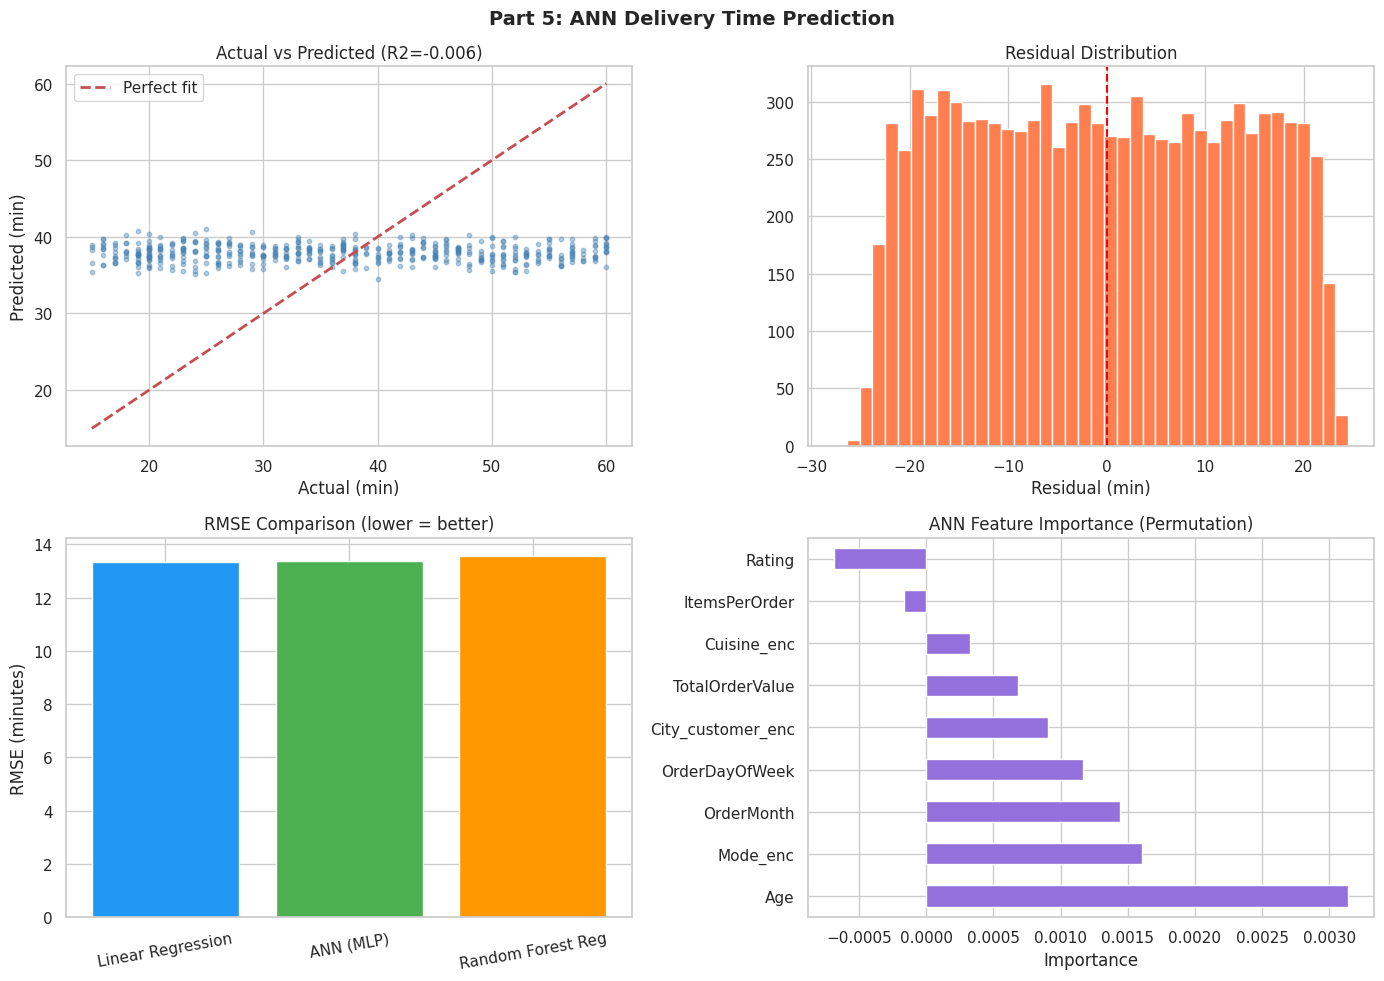

Part 5 complete


In [27]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Part 5: ANN Delivery Time Prediction', fontsize=14, fontweight='bold')

sample = min(500, len(y_te))
axes[0,0].scatter(y_te[:sample], y_pred_ann[:sample], alpha=0.4, s=10, color='steelblue')
lims = [min(y_te.min(), y_pred_ann.min()), max(y_te.max(), y_pred_ann.max())]
axes[0,0].plot(lims, lims, 'r--', lw=2, label='Perfect fit')
axes[0,0].set_xlabel('Actual (min)'); axes[0,0].set_ylabel('Predicted (min)')
axes[0,0].set_title(f'Actual vs Predicted (R2={ann_r2:.3f})')
axes[0,0].legend()

residuals = y_te - y_pred_ann
axes[0,1].hist(residuals, bins=40, color='coral', edgecolor='white')
axes[0,1].axvline(0, color='red', linestyle='--')
axes[0,1].set_title('Residual Distribution'); axes[0,1].set_xlabel('Residual (min)')

colors_bar = ['#2196F3','#4CAF50','#FF9800']
axes[1,0].bar(reg_df['Model'], reg_df['RMSE'], color=colors_bar)
axes[1,0].set_title('RMSE Comparison (lower = better)')
axes[1,0].set_ylabel('RMSE (minutes)')
axes[1,0].tick_params(axis='x', rotation=10)

ann_feat_imp.plot(kind='barh', ax=axes[1,1], color='mediumpurple')
axes[1,1].set_title('ANN Feature Importance (Permutation)')
axes[1,1].set_xlabel('Importance')

plt.tight_layout()
plt.show()
print('Part 5 complete')

---
## PART 6: Business Insights

In [28]:
print('=' * 60)
print('BUSINESS INSIGHTS SUMMARY')
print('=' * 60)

top_rests = df.groupby('RestaurantID').agg(
    TotalRevenue=('TotalOrderValue','sum'),
    AvgRating=('Rating','mean'),
    OrderCount=('OrderID','count'),
    OnTimeRate=('Status', lambda x: (x=='OnTime').mean())
).sort_values('TotalRevenue', ascending=False).head(5)

print('\nTop 5 Restaurants by Revenue:')
display(top_rests.round(2))

hv_customers = cust_seg[cust_seg['KMeans_Cluster'] == max_spend_cluster]
print(f'\nHigh-Value Customer Cluster ({max_spend_cluster}): {len(hv_customers):,} customers')
print(f'  Avg Spending: {hv_customers["TotalSpending"].mean():,.0f}')
print(f'  Avg Orders  : {hv_customers["OrderFrequency"].mean():.1f}')

late_rate   = (df['Status'] == 'Late').mean()
cancel_rate = (df['Status'] == 'Cancelled').mean()
print(f'\nDelivery Bottlenecks:')
print(f'  Late delivery rate  : {late_rate:.1%}')
print(f'  Cancellation rate   : {cancel_rate:.1%}')

worst_cuisine = df[df['Status']=='Late'].groupby('Cuisine')['OrderID'].count().sort_values(ascending=False).head(3)
print('\n  Top cuisines with late deliveries:')
display(worst_cuisine)

print(f'\nBest Classification Model  : {metrics_df.iloc[0]["Model"]} (F1={metrics_df.iloc[0]["F1"]:.3f})')
print(f'Best Delivery Time Predictor: {reg_df.iloc[0]["Model"]} (RMSE={reg_df.iloc[0]["RMSE"]:.2f} min)')
print(f'Association rules found     : {len(rules)} rules')
print(f'Customer segments           : {optimal_k} clusters')

BUSINESS INSIGHTS SUMMARY

Top 5 Restaurants by Revenue:


,TotalRevenue,AvgRating,OrderCount,OnTimeRate
RestaurantID,,,,
311,113429,2.6,135,0.33
39,112047,3.6,127,0.29
59,110750,4.6,130,0.36
202,110726,3.9,123,0.35
235,108106,4.7,124,0.33



High-Value Customer Cluster (0): 10,500 customers
  Avg Spending: 2,275
  Avg Orders  : 2.5

Delivery Bottlenecks:
  Late delivery rate  : 33.7%
  Cancellation rate   : 33.1%

  Top cuisines with late deliveries:


,OrderID
Cuisine,
Dessert,4073
FastFood,3559
Italian,3209



Best Classification Model  : SVM (F1=0.343)
Best Delivery Time Predictor: Linear Regression (RMSE=13.35 min)
Association rules found     : 36 rules
Customer segments           : 3 clusters


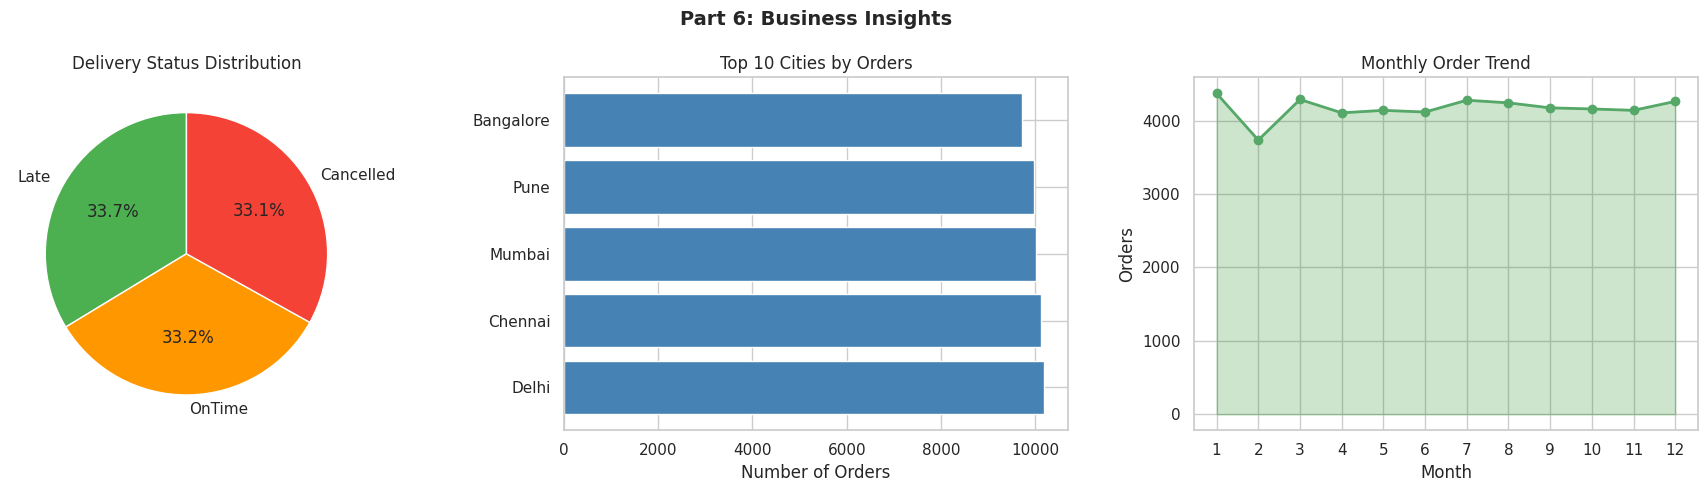

All parts complete!


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Part 6: Business Insights', fontsize=14, fontweight='bold')

status_counts = df['Status'].value_counts()
axes[0].pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%',
            colors=['#4CAF50','#FF9800','#F44336'], startangle=90)
axes[0].set_title('Delivery Status Distribution')

city_orders = df['City_customer'].value_counts().head(10)
axes[1].barh(city_orders.index, city_orders.values, color='steelblue')
axes[1].set_title('Top 10 Cities by Orders')
axes[1].set_xlabel('Number of Orders')

monthly = df.groupby('OrderMonth')['OrderID'].count()
axes[2].plot(monthly.index, monthly.values, 'go-', linewidth=2, markersize=6)
axes[2].fill_between(monthly.index, monthly.values, alpha=0.2, color='green')
axes[2].set_title('Monthly Order Trend')
axes[2].set_xlabel('Month'); axes[2].set_ylabel('Orders')
axes[2].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()
print('All parts complete!')

---
## Project Summary

| Part | Technique | Key Output |
|------|-----------|------------|
| 1 | Data Integration & EDA | Merged 7 sheets, 6 derived features |
| 2 | Apriori + FP-Growth | Association rules (Support, Confidence, Lift) |
| 3 | LR, DT, RF, SVM | Delivery Status classification + confusion matrices |
| 4 | K-Means + Hierarchical | 3 customer segments: High-Value, Frequent, Regular |
| 5 | ANN (MLPRegressor 128-64-32) | Delivery time regression vs baselines |
| 6 | Business Insights | Top restaurants, bottlenecks, trends |